🌿 Plant Disease Classification — Kaggle Plant Pathology 2021

Multi-label image classification using PyTorch & EfficientNet-B0.
Notebook trains an EfficientNet-B0 model on 18K+ leaf images, including full data pipeline, training logs, and an inference demo (upload an image to test predictions).

Dataset: https://www.kaggle.com/c/plant-pathology-2021


In [1]:
# Environment & imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("✅ imports ok — torch:", torch.__version__)

✅ imports ok — torch: 2.6.0+cu124


/usr/local/lib/python3.11/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [2]:
train_df = pd.read_csv("/kaggle/input/plant-pathology-2021-fgvc8/train.csv")
train_df['labels'] = train_df['labels'].apply(lambda x: x.split())
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(train_df['labels'])
print("Classes:", mlb.classes_)
train_df.head()

Classes: ['complex' 'frog_eye_leaf_spot' 'healthy' 'powdery_mildew' 'rust' 'scab']


,image,labels
0,800113bb65efe69e.jpg,[healthy]
1,8002cb321f8bfcdf.jpg,"[scab, frog_eye_leaf_spot, complex]"
2,80070f7fb5e2ccaa.jpg,[scab]
3,80077517781fb94f.jpg,[scab]
4,800cbf0ff87721f8.jpg,[complex]


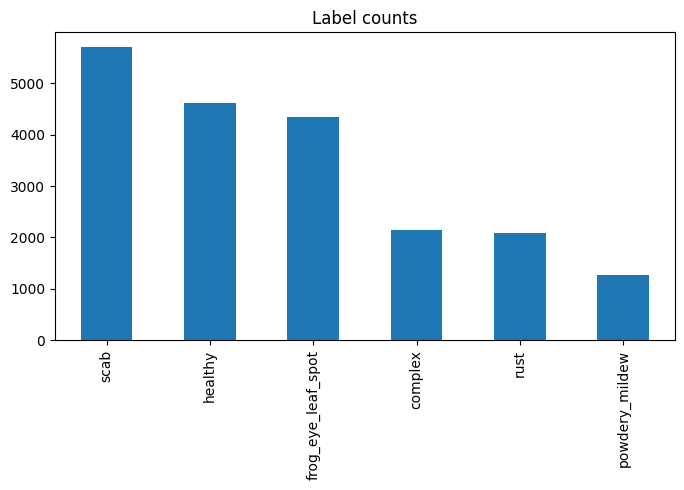

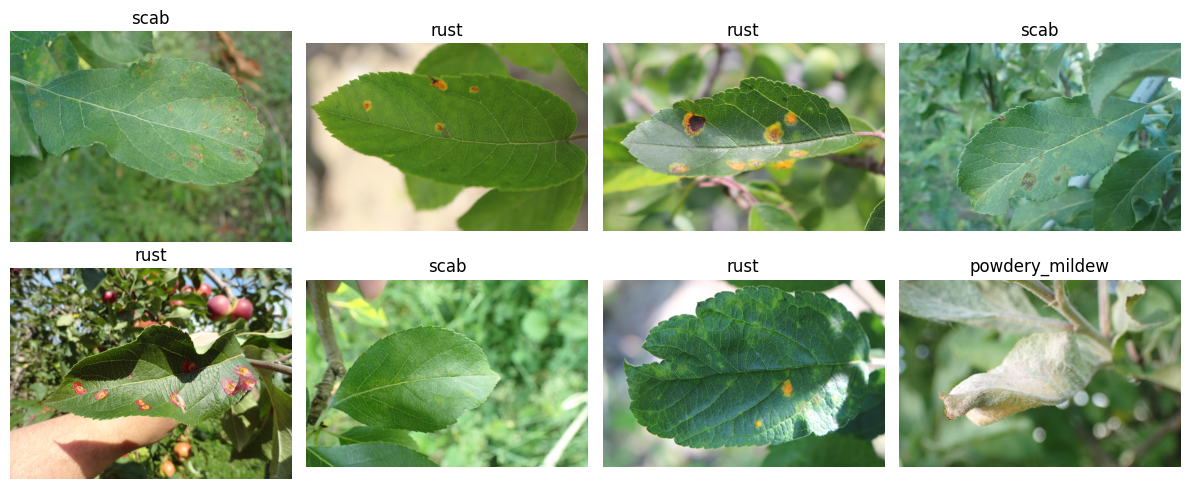

In [3]:
# class counts (multi-label -> count each label presence)
from collections import Counter
cnt = Counter([label for labels in train_df['labels'] for label in labels])
pd.Series(dict(cnt)).sort_values(ascending=False).plot.bar(figsize=(8,4))
plt.title("Label counts")

# show a grid of sample images
def show_samples(df, img_dir, n=8):
    fig, axes = plt.subplots(2, n//2, figsize=(12,5))
    for ax, (_, row) in zip(axes.flatten(), df.sample(n).iterrows()):
        img = Image.open(os.path.join(img_dir, row.image)).convert("RGB")
        ax.imshow(img)
        ax.set_title(", ".join(row.labels))
        ax.axis('off')
    plt.tight_layout()

show_samples(train_df, "/kaggle/input/plant-pathology-2021-fgvc8/train_images/")

In [4]:
class PlantDataset(Dataset):
    def __init__(self, df, labels, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df.iloc[idx, 0])
        image = np.array(Image.open(img_path).convert("RGB"))
        label = torch.tensor(self.labels[idx]).float()
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label

In [5]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

train_dataset = PlantDataset(
    train_df, y,
    "/kaggle/input/plant-pathology-2021-fgvc8/train_images/",
    transform=train_transform
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

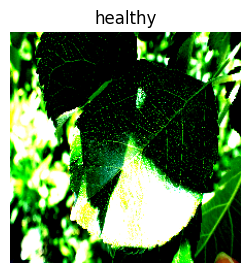

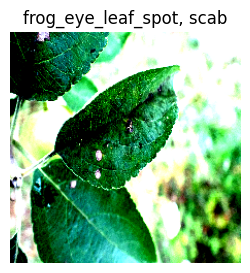

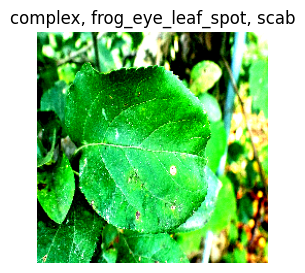

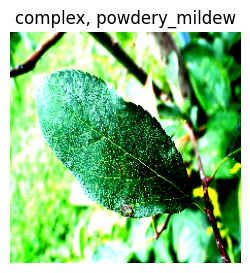

In [6]:
class_names = mlb.classes_
import matplotlib.pyplot as plt

# Sample 4 random rows
sample_idx = train_df.sample(4, random_state=42).index
sample = PlantDataset(train_df.loc[sample_idx], y[sample_idx], "/kaggle/input/plant-pathology-2021-fgvc8/train_images/", transform=train_transform)

# Plot
for i, (img, lbl) in enumerate(sample):
    plt.figure(figsize=(3,3))
    plt.imshow(img.permute(1, 2, 0).numpy())
    
    # Convert multi-hot label vector to readable class names
    active_classes = [class_names[j] for j, val in enumerate(lbl.numpy()) if val == 1.0]
    plt.title(", ".join(active_classes))
    plt.axis('off')
    plt.show()

In [7]:
# instantiate model
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(mlb.classes_))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# simple training loop (show only final loss)
for epoch in range(3):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/3], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/3], Loss: 0.4061
Epoch [2/3], Loss: 0.3193
Epoch [3/3], Loss: 0.2720


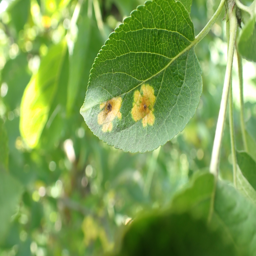

True: ['rust'] Predicted: ['rust']


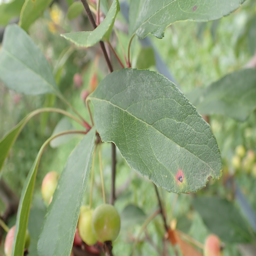

True: ['powdery_mildew', 'complex'] Predicted: ['complex']


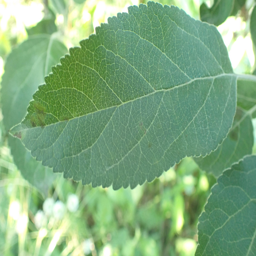

True: ['scab'] Predicted: ['healthy']


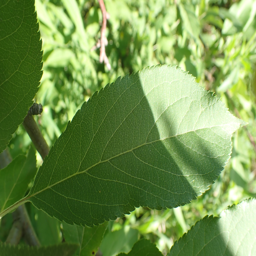

True: ['healthy'] Predicted: ['healthy']


In [8]:
# load weights if saved
# model.load_state_dict(torch.load("plant_model.pth", map_location=device))
model.eval()

def predict_pil(img_pil, threshold=0.5):
    img = np.array(img_pil.convert("RGB"))
    transform = A.Compose([A.Resize(224,224), A.Normalize(), ToTensorV2()])
    x = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    labels = [mlb.classes_[i] for i,v in enumerate(probs) if v >= threshold]
    return labels, probs

# show predictions on random samples
for idx in train_df.sample(4).index:
    img = Image.open(os.path.join("/kaggle/input/plant-pathology-2021-fgvc8/train_images/", train_df.loc[idx,'image']))
    labels, probs = predict_pil(img)
    display(img.resize((256,256)))
    print("True:", train_df.loc[idx,'labels'], "Predicted:", labels)

In [9]:
torch.save(model.state_dict(), "plant_model_demo.pth")
# Save a small CSV of a few sample predictions to display in notebook
sample_preds = []
for idx in train_df.sample(200).index:
    img_path = os.path.join("/kaggle/input/plant-pathology-2021-fgvc8/train_images/", train_df.loc[idx,'image'])
    labels, probs = predict_pil(Image.open(img_path))
    sample_preds.append((train_df.loc[idx,'image'], train_df.loc[idx,'labels'], labels))
pd.DataFrame(sample_preds, columns=["image","true","pred"]).to_csv("sample_predictions.csv", index=False)

## 🧠 Inference Demo
This section shows how to use the trained EfficientNet-B0 model to predict diseases on unseen leaf images.

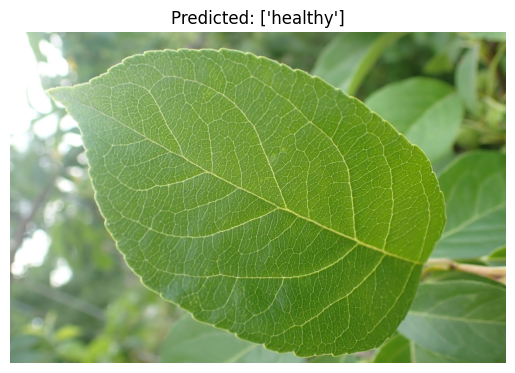

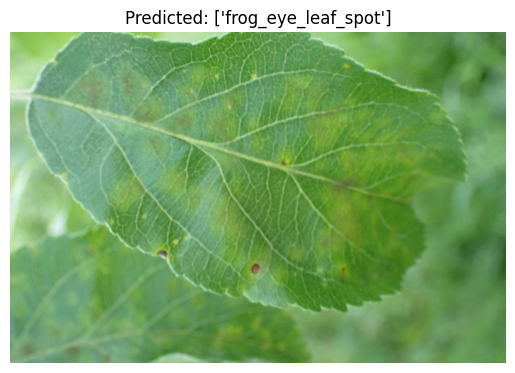

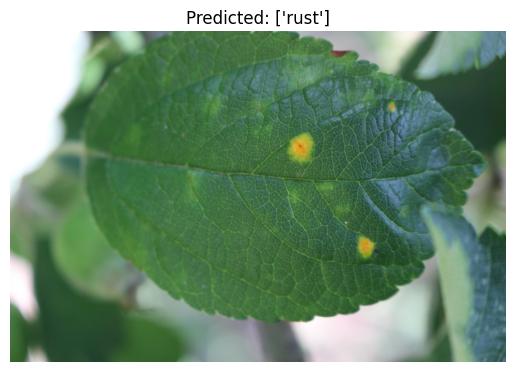

In [10]:
import torch
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

# Load model (must match your training setup)
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)  # 6 = number of classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(torch.load("/kaggle/input/plant-model/pytorch/default/1/plant_model.pth", map_location=device))
model = model.to(device)
model.eval()

# Label names (same order used during training)
labels = ['complex', 'frog_eye_leaf_spot', 'healthy', 'powdery_mildew', 'rust', 'scab']

# Transform for inference
inference_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

def predict_image(image_path, threshold=0.5):
    img = np.array(Image.open(image_path).convert("RGB"))
    img_tensor = inference_transform(image=img)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    predicted_labels = [labels[i] for i, p in enumerate(probs) if p >= threshold]
    return predicted_labels, probs

# Pick a few random test images
test_dir = "/kaggle/input/plant-pathology-2021-fgvc8/train_images/"
sample_images = [
    "fffe472a0001bd25.jpg",  # healthy
    "fffe105cf6808292.jpg",  # scab frog_eye_leaf_spot
    "fffc94e092a59086.jpg",  # rust
]

for img_name in sample_images:
    path = test_dir + img_name
    preds, probs = predict_image(path)
    plt.imshow(Image.open(path))
    plt.axis('off')
    plt.title(f"Predicted: {preds}")
    plt.show()

In [11]:
# For testing uploaded image

# from PIL import Image
# import torchvision.transforms as transforms

# # Example: test on an uploaded image
# img_path = "/kaggle/input/test-image.jpg"  # update this with your test image
# img = Image.open(img_path).convert("RGB")

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# input_tensor = transform(img).unsqueeze(0).to(device)
# with torch.no_grad():
#     outputs = model(input_tensor)
#     _, predicted = torch.max(outputs, 1)

# print("Predicted class index:", predicted.item())